### Bank Customers Churn Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read the Data Set

df = pd.read_csv("C:/Users/sagar/OneDrive/Desktop/Bank_Customer_Churn_Analysis/data/bank_churn.csv")
df.head()

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Account_Tenure_Months,Account_Type,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
0,CUST2463,32,Male,Divorced,Primary,Employed,13,Current,2,57001,19,6,10,0,0.97,0,1,0,0,1
1,CUST2511,45,Male,Single,University,Employed,88,Current,1,24533,14,5,9,0,0.89,2,1,0,0,0
2,CUST2227,29,Female,Single,Primary,Employed,151,Savings,3,212133,16,11,7,1,0.71,2,1,0,0,0
3,CUST0526,49,Female,Single,Secondary,Employed,118,Savings,2,94045,22,12,8,0,0.89,0,1,0,0,0
4,CUST0195,33,Female,Single,Primary,Employed,108,Savings,1,137693,15,7,8,0,0.64,1,0,0,0,0


In [ ]:
# Look the Shape ( row , col ) 
df.shape


(10000, 20)

In [ ]:
# Check the Column names
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Education_Level',
       'Employment_Status', 'Account_Tenure_Months', 'Account_Type',
       'Number_of_Products', 'Average_Balance', 'Monthly_Transactions',
       'Online_Banking_Usage', 'Mobile_Banking_Usage', 'Number_of_Complaints',
       'Complaint_Resolution_Rate', 'Customer_Support_Calls', 'Email_Opt_In',
       'Credit_Card_Holder', 'Loan_Account_Holder', 'Churn'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                10000 non-null  object 
 1   Age                        10000 non-null  int64  
 2   Gender                     10000 non-null  object 
 3   Marital_Status             10000 non-null  object 
 4   Education_Level            8974 non-null   object 
 5   Employment_Status          10000 non-null  object 
 6   Account_Tenure_Months      10000 non-null  int64  
 7   Account_Type               10000 non-null  object 
 8   Number_of_Products         10000 non-null  int64  
 9   Average_Balance            10000 non-null  int64  
 10  Monthly_Transactions       10000 non-null  int64  
 11  Online_Banking_Usage       10000 non-null  int64  
 12  Mobile_Banking_Usage       10000 non-null  int64  
 13  Number_of_Complaints       10000 non-null  int6

In [ ]:
# Discriptions of the dataset 
df.describe()

,Age,Account_Tenure_Months,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
count,10000.00000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,35.15840,90.817100,2.005800,1.501083e+05,15.053100,8.00500,10.027600,0.193300,0.747475,1.01120,0.691600,0.298300,0.206900,0.273200
std,9.62961,51.771835,1.005021,1.513211e+05,3.870294,2.85198,3.175791,0.437898,0.144261,1.00746,0.461856,0.457535,0.405103,0.445625
min,18.00000,1.000000,1.000000,5.000000e+02,3.000000,0.00000,0.000000,0.000000,0.500000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,28.00000,46.000000,1.000000,4.422200e+04,12.000000,6.00000,8.000000,0.000000,0.620000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,35.00000,91.000000,2.000000,1.036505e+05,15.000000,8.00000,10.000000,0.000000,0.750000,1.00000,1.000000,0.000000,0.000000,0.000000
75%,42.00000,136.000000,3.000000,2.065610e+05,18.000000,10.00000,12.000000,0.000000,0.870000,2.00000,1.000000,1.000000,0.000000,1.000000
max,70.00000,180.000000,4.000000,1.644080e+06,32.000000,21.00000,27.000000,3.000000,1.000000,7.00000,1.000000,1.000000,1.000000,1.000000


#### Data Cleaning

In [ ]:
#Checking the NUll Values 
df.isnull().sum()

Customer_ID                     0
Age                             0
Gender                          0
Marital_Status                  0
Education_Level              1026
Employment_Status               0
Account_Tenure_Months           0
Account_Type                    0
Number_of_Products              0
Average_Balance                 0
Monthly_Transactions            0
Online_Banking_Usage            0
Mobile_Banking_Usage            0
Number_of_Complaints            0
Complaint_Resolution_Rate       0
Customer_Support_Calls          0
Email_Opt_In                    0
Credit_Card_Holder              0
Loan_Account_Holder             0
Churn                           0
dtype: int64

In [ ]:
# Percentage of NUll Values in data
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Percentage
Education_Level,1026,10.26


In [ ]:
# Churn Percentage With Education Level
pd.crosstab(
    df["Education_Level"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Education_Level,,
Primary,72.813239,27.186761
Secondary,72.690864,27.309136
University,72.299306,27.700694


In [ ]:
# Replace the Null values With Not Available
df["Education_Level"] = df["Education_Level"].fillna("Not Available")

In [ ]:
# Check the Replaced values
print(df["Education_Level"].isnull().sum())

0


In [ ]:
#Count of total values by Education_Level
print(df["Education_Level"].value_counts())

Education_Level
Secondary        3995
Primary          2961
University       2018
Not Available    1026
Name: count, dtype: int64


In [ ]:
#Check The duplicate Values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Drop Duplicate Values
df = df.drop_duplicates()

In [ ]:
#Checking the Data Types of Each Column In the data
df.dtypes

Customer_ID                   object
Age                            int64
Gender                        object
Marital_Status                object
Education_Level               object
Employment_Status             object
Account_Tenure_Months          int64
Account_Type                  object
Number_of_Products             int64
Average_Balance                int64
Monthly_Transactions           int64
Online_Banking_Usage           int64
Mobile_Banking_Usage           int64
Number_of_Complaints           int64
Complaint_Resolution_Rate    float64
Customer_Support_Calls         int64
Email_Opt_In                   int64
Credit_Card_Holder             int64
Loan_Account_Holder            int64
Churn                          int64
dtype: object

In [39]:
# Check minimum and maximum values

print("Age:", df["Age"].min(), "-", df["Age"].max())

print("Account Tenure:", 
      df["Account_Tenure_Months"].min(), "-", 
      df["Account_Tenure_Months"].max())

print("Number of Products:", 
      df["Number_of_Products"].min(), "-", 
      df["Number_of_Products"].max())

print("Average Balance:", 
      df["Average_Balance"].min(), "-", 
      df["Average_Balance"].max())

print("Monthly Transactions:", 
      df["Monthly_Transactions"].min(), "-", 
      df["Monthly_Transactions"].max())

print("Online Banking Usage:", 
      df["Online_Banking_Usage"].min(), "-", 
      df["Online_Banking_Usage"].max())

print("Mobile Banking Usage:", 
      df["Mobile_Banking_Usage"].min(), "-", 
      df["Mobile_Banking_Usage"].max())

print("Number of Complaints:", 
      df["Number_of_Complaints"].min(), "-", 
      df["Number_of_Complaints"].max())

print("Customer Support Calls:", 
      df["Customer_Support_Calls"].min(), "-", 
      df["Customer_Support_Calls"].max())

print("Churn:", 
      df["Churn"].min(), "-", 
      df["Churn"].max())

Age: 18 - 70
Account Tenure: 1 - 180
Number of Products: 1 - 4
Average Balance: 500 - 1644080
Monthly Transactions: 3 - 32
Online Banking Usage: 0 - 21
Mobile Banking Usage: 0 - 27
Number of Complaints: 0 - 3
Customer Support Calls: 0 - 7
Churn: 0 - 1


## Exploratory Data Analysis

### 1. Customer Churn Distribution

In [40]:
# Churn Distribution

churn_counts = df["Churn"].value_counts()

print(churn_counts)

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
0    7268
1    2732
Name: count, dtype: int64

Churn Percentage:
Churn
0    72.68
1    27.32
Name: proportion, dtype: float64


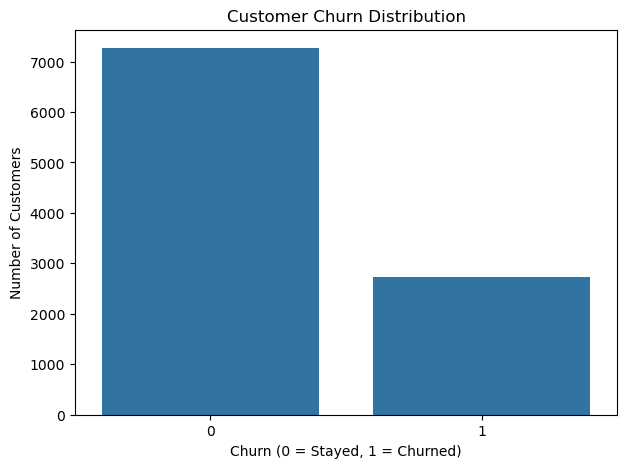

In [41]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

### 2. Churn by Account Type

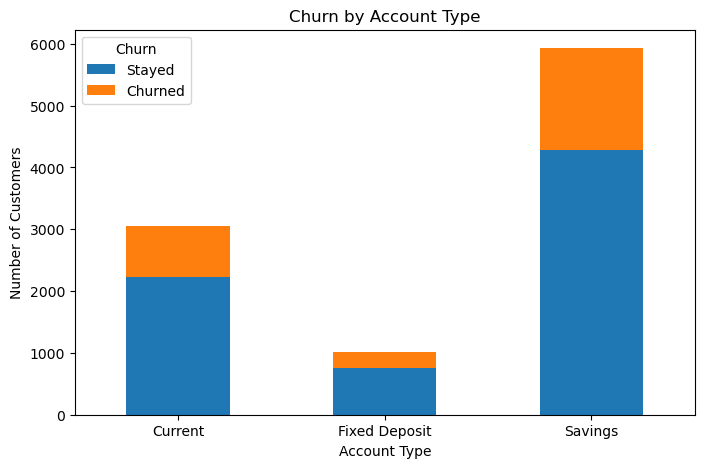

In [42]:
# Churn by Account Type

account_churn = pd.crosstab(
    df["Account_Type"],
    df["Churn"]
)

account_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(
    title="Churn",
    labels=["Stayed", "Churned"]
)

plt.show()

### 3. Churn Rate by Education Level

In [43]:
# Calculate churn percentage by education level

education_churn = pd.crosstab(
    df["Education_Level"],
    df["Churn"],
    normalize="index"
) * 100

print(education_churn)

Churn                    0          1
Education_Level                      
Not Available    73.001949  26.998051
Primary          72.813239  27.186761
Secondary        72.690864  27.309136
University       72.299306  27.700694


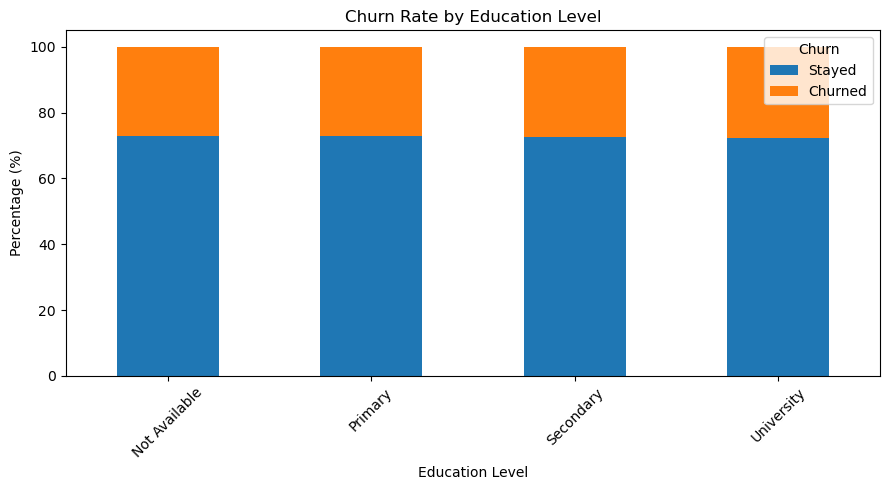

In [44]:
# 100% stacked bar chart

education_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Churn Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(
    title="Churn",
    labels=["Stayed", "Churned"]
)

plt.tight_layout()
plt.show()

### 4. Age Distribution of Churned vs Stayed Customers

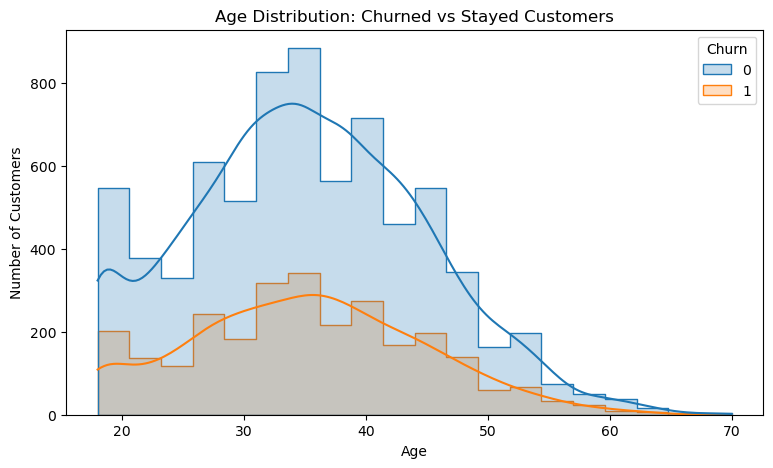

In [ ]:
# Age Distribution: Churned vs Stayed Customers

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Churn",
    bins=20,
    kde=True,
    element="step"
)

plt.title("Age Distribution: Churned vs Stayed Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### 5. Average Balance vs Customer Churn

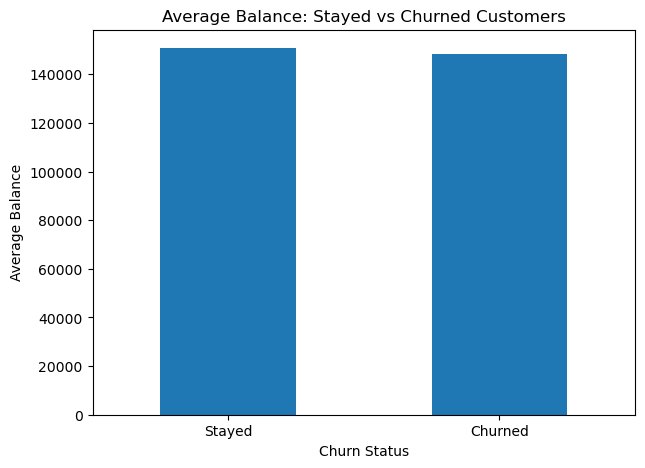

In [47]:
# Average Balance by Churn Status

balance_churn = df.groupby("Churn")["Average_Balance"].mean()

balance_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Balance: Stayed vs Churned Customers")
plt.xlabel("Churn Status")
plt.ylabel("Average Balance")
plt.xticks([0, 1], ["Stayed", "Churned"], rotation=0)

plt.show()

### 6.Churn Rate by Number of Complaints

Number_of_Complaints
0    26.526648
1    30.399501
2    36.184211
3    55.555556
Name: Churn, dtype: float64


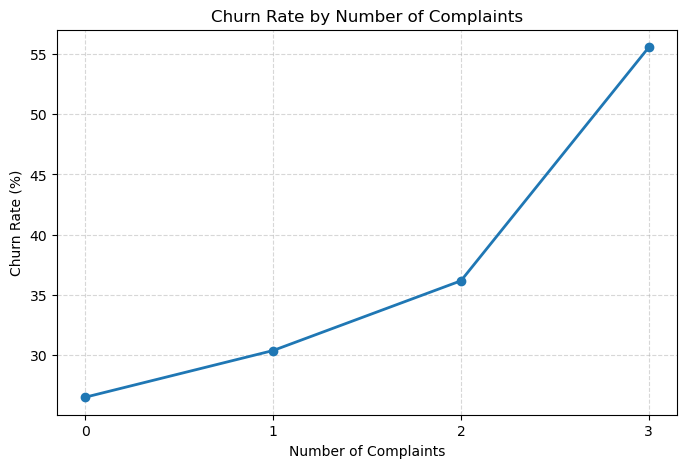

In [ ]:
# Churn Rate by Number of Complaints BY Line chart

complaint_churn = df.groupby("Number_of_Complaints")["Churn"].mean() * 100

print(complaint_churn)
plt.figure(figsize=(8, 5))

plt.plot(
    complaint_churn.index,
    complaint_churn.values,
    marker="o",
    linewidth=2
)

plt.title("Churn Rate by Number of Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("Churn Rate (%)")
plt.xticks(complaint_churn.index)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### 7.Online vs Mobile Banking Usage by Churn


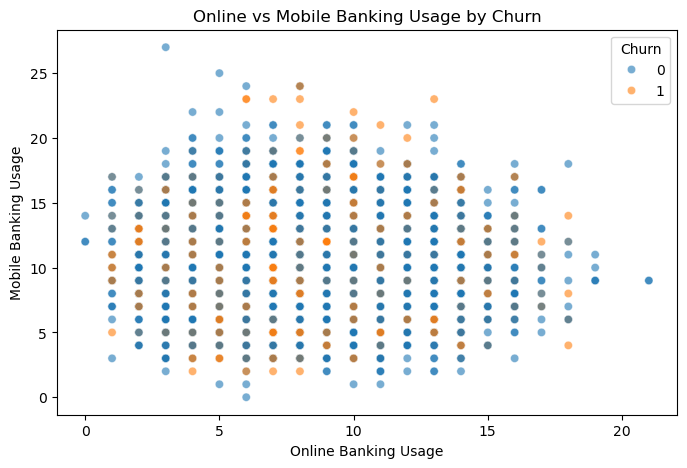

In [ ]:
# Online vs Mobile Banking Usage by Churn

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Online_Banking_Usage",
    y="Mobile_Banking_Usage",
    hue="Churn",
    alpha=0.6
)

plt.title("Online vs Mobile Banking Usage by Churn")
plt.xlabel("Online Banking Usage")
plt.ylabel("Mobile Banking Usage")

plt.show()

### 8. Churn Rate by Number of Products

In [ ]:
product_churn = (
    df.groupby("Number_of_Products")["Churn"]
    .mean()
    .mul(100)
    .sort_values()
)

print(product_churn)

Number_of_Products
4    26.208897
3    26.757714
1    27.514422
2    27.814790
Name: Churn, dtype: float64


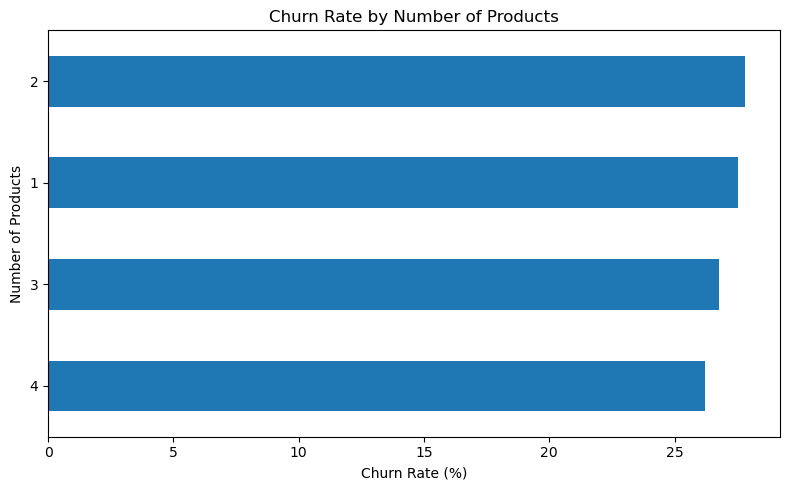

In [ ]:
# Churn Rate by Number of Products

plt.figure(figsize=(8, 5))

product_churn.plot(
    kind="barh"
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

### 9.Churn by Loan Account Holder

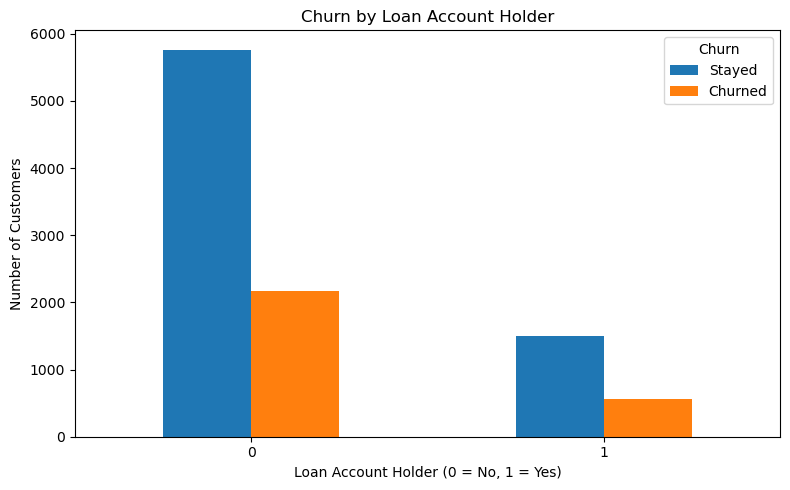

In [54]:
# Churn by Loan Account Holder

loan_churn = pd.crosstab(
    df["Loan_Account_Holder"],
    df["Churn"]
)

loan_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn by Loan Account Holder")
plt.xlabel("Loan Account Holder (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(
    title="Churn",
    labels=["Stayed", "Churned"]
)

plt.tight_layout()
plt.show()

### 10.Churn Rate by Credit Card Holder

Churn                       0          1
Credit_Card_Holder                      
0                   72.865897  27.134103
1                   72.242709  27.757291


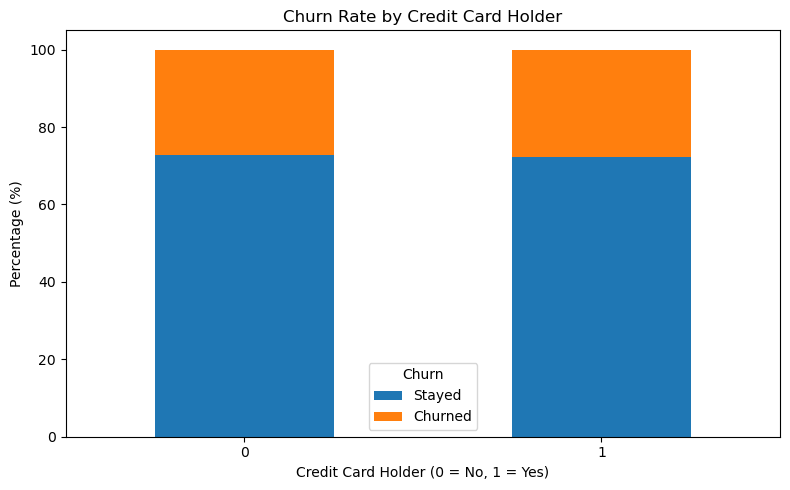

In [56]:
# Churn Rate by Credit Card Holder

credit_churn = (
    pd.crosstab(
        df["Credit_Card_Holder"],
        df["Churn"],
        normalize="index"
    ) * 100
)

print(credit_churn)

credit_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Credit Card Holder")
plt.xlabel("Credit Card Holder (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Churn",
    labels=["Stayed", "Churned"]
)

plt.tight_layout()
plt.show()

### 11.Correlation Heatmap of Customer Churn Data

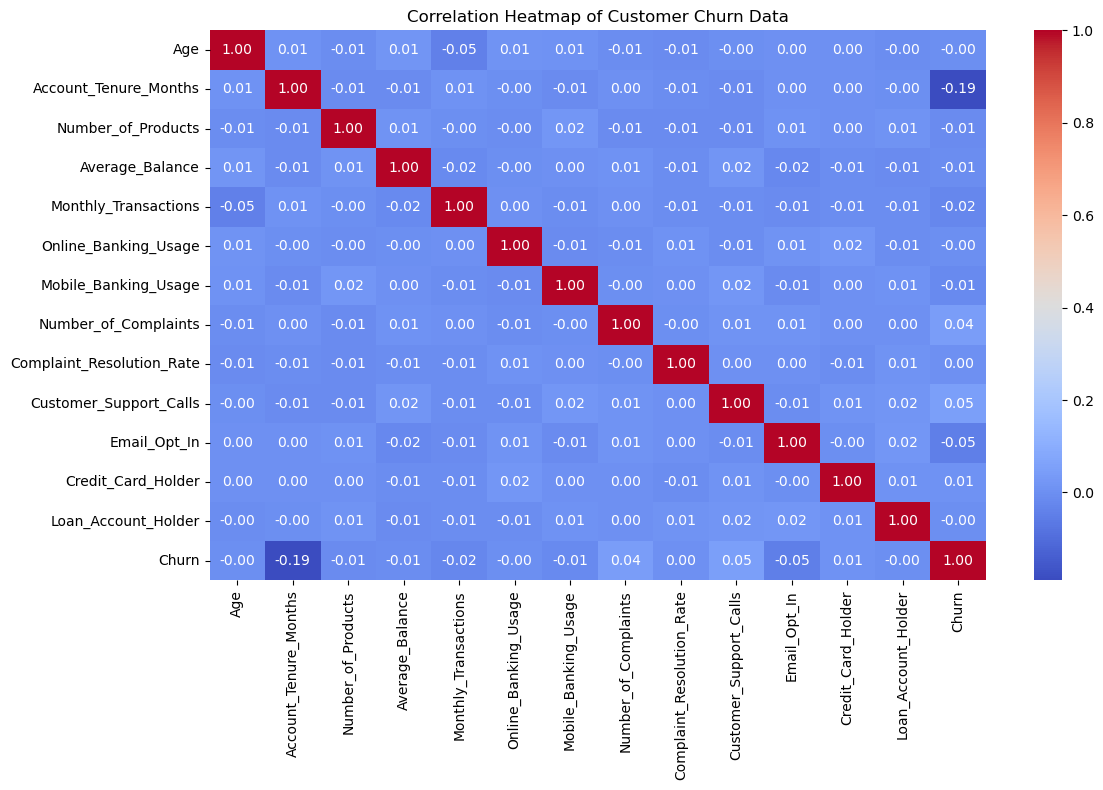

In [57]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Customer Churn Data")
plt.tight_layout()
plt.show()

## EDA Insights

1. The dataset contains 10,000 bank customers.

2. 2,732 customers have churned, while 7,268 customers have stayed.

3. The overall customer churn rate is 27.32%.

4. Education_Level contained 1,026 missing values. These were replaced with "Not Available" instead of removing customers.

5. The dataset contains no duplicate rows.

6. Customer complaints and customer support interactions can be analyzed as important customer-service factors associated with churn.

7. Account type and number of products show differences in churn behavior across customer groups.

8. Banking usage patterns, including online and mobile banking usage, can be compared between churned and retained customers.

9. Loan and credit-card ownership provide additional customer characteristics for understanding churn patterns.

10. The correlation analysis helps identify numerical variables that may have stronger relationships with customer churn.